In [1]:
def funcion(x, y):
    sum1 = x**2 * (4 - 2.1*x**2 + x**4 / 3.0)
    sum2 = x * y
    sum3 = y**2 * (-4 + 4*y**2)
    return sum1 + sum2 + sum3

In [2]:
import numpy as np

def busqueda_grilla(infx=-2.0, supx=2.0, infy=-1.0, supy=1.0, pasos=1000):

    mejor_x    = infx
    mejor_y    = infy
    mejor_val  = funcion(infx, infy)

    xs = np.linspace(infx, supx, pasos)
    ys = np.linspace(infy, supy, pasos)

    for x in xs:
        for y in ys:
            val = funcion(x, y)
            if val < mejor_val:
                mejor_val = val
                mejor_x   = x
                mejor_y   = y

    return mejor_x, mejor_y, mejor_val


x_grid, y_grid, f_grid = busqueda_grilla()

print("=== Programación estructurada (grilla) ===")
print(f"  x        = {x_grid:.6f}")
print(f"  y        = {y_grid:.6f}")
print(f"  f(x,y)   = {f_grid:.6f}")
print(f"  Referencia: f ≈ -1.031628")

=== Programación estructurada (grilla) ===
  x        = -0.090090
  y        = 0.711712
  f(x,y)   = -1.031621
  Referencia: f ≈ -1.031628


In [3]:
from random import random

# Función que se quiere minimizar
def funcion(x, y):
    sum1 = x**2 * (4 - 2.1*x**2 + x**4 / 3.0)
    sum2 = x * y
    sum3 = y**2 * (-4 + 4*y**2)
    return sum1 + sum2 + sum3

# Devuelve un número aleatorio dentro de un rango con
# distribución uniforme (proporcionada por random)
def aleatorio(inf, sup):
    return random() * (sup - inf) + inf

In [4]:
# Clase que representa una partícula individual y que facilita
# las operaciones necesarias
class Particula:
    # Atributos de clase (comunes a todas las partículas)
    # Parámetros para actualizar la velocidad
    inercia   = 1.4
    cognitiva = 2.0
    social    = 2.0
    # Límites del espacio de soluciones
    infx  = -2.0
    supx  =  2.0
    infy  = -1.0
    supy  =  1.0
    # Factor de ajuste de la velocidad inicial
    ajusteV = 100.0

    # Crea una partícula dentro de los límites indicados
    def __init__(self):
        self.x  = aleatorio(Particula.infx, Particula.supx)
        self.y  = aleatorio(Particula.infy, Particula.supy)
        self.vx = aleatorio(Particula.infx / Particula.ajusteV,
                            Particula.supx / Particula.ajusteV)
        self.vy = aleatorio(Particula.infy / Particula.ajusteV,
                            Particula.supy / Particula.ajusteV)
        self.xLoc     = self.x
        self.yLoc     = self.y
        self.valorLoc = funcion(self.x, self.y)

    # Actualiza la velocidad de la partícula
    def actualizaVelocidad(self, xGlob, yGlob):
        cogX    = Particula.cognitiva * random() * (self.xLoc - self.x)
        socX    = Particula.social    * random() * (xGlob    - self.x)
        self.vx = Particula.inercia   * self.vx + cogX + socX

        cogY    = Particula.cognitiva * random() * (self.yLoc - self.y)
        socY    = Particula.social    * random() * (yGlob    - self.x)  # tal cual libro
        self.vy = Particula.inercia   * self.vy + cogY + socY

    # Actualiza la posición de la partícula
    def actualizaPosicion(self):
        self.x = self.x + self.vx
        self.y = self.y + self.vy

        # Debe mantenerse dentro del espacio de soluciones
        self.x = max(self.x, Particula.infx)
        self.x = min(self.x, Particula.supx)
        self.y = max(self.y, Particula.infy)
        self.y = min(self.y, Particula.supy)

        # Si es inferior a la mejor, la adopta como mejor
        valor = funcion(self.x, self.y)
        if valor < self.valorLoc:
            self.xLoc     = self.x
            self.yLoc     = self.y
            self.valorLoc = valor

In [5]:
# Mueve un enjambre de partículas durante las iteraciones indicadas.
# Devuelve las coordenadas y el valor del mínimo obtenido.
def enjambreParticulas(particulas, iteraciones, reduccionInercia):

    # Registra la mejor posición global y su valor
    mejorParticula = min(particulas, key=lambda p: p.valorLoc)
    xGlob     = mejorParticula.xLoc
    yGlob     = mejorParticula.yLoc
    valorGlob = mejorParticula.valorLoc

    for iter in range(iteraciones):
        # Actualiza la velocidad y posición de cada partícula
        for p in particulas:
            p.actualizaVelocidad(xGlob, yGlob)
            p.actualizaPosicion()

        # Hasta que no se han movido todas las partículas no se
        # actualiza el mínimo global, para simular que todas se
        # mueven a la vez
        mejorParticula = min(particulas, key=lambda p: p.valorLoc)
        if mejorParticula.valorLoc < valorGlob:
            xGlob     = mejorParticula.xLoc
            yGlob     = mejorParticula.yLoc
            valorGlob = mejorParticula.valorLoc

        # Finalmente se reduce la inercia de las partículas
        Particula.inercia *= reduccionInercia

    return (xGlob, yGlob, valorGlob)

In [6]:
# Parámetros del problema
nParticulas  = 10
iteraciones  = 100
redInercia   = 0.9

# Genera un conjunto inicial de partículas
Particula.inercia = 1.4          # reinicia inercia al valor inicial del libro
particulas = [Particula() for i in range(nParticulas)]

# Ejecuta el algoritmo del enjambre de partículas
resultado = enjambreParticulas(particulas, iteraciones, redInercia)

print("=== PSO — Benítez Iglésias (2014) ===")
print(f"  x        = {resultado[0]:.6f}")
print(f"  y        = {resultado[1]:.6f}")
print(f"  f(x,y)   = {resultado[2]:.6f}")
print(f"  Referencia: f ≈ -1.031628")

=== PSO — Benítez Iglésias (2014) ===
  x        = -0.101639
  y        = 0.712426
  f(x,y)   = -1.031084
  Referencia: f ≈ -1.031628


**Comparacion**

Método                             x          y       f(x,y)    Error abs
------------------------------------------------------------------------
Grilla (estructurada)      -0.090090   0.711712    -1.031621     7.32e-06
PSO (Benítez 2014)         -0.101639   0.712426    -1.031084     5.44e-04

Referencia                 ±0.089843  ∓0.712656    -1.031628


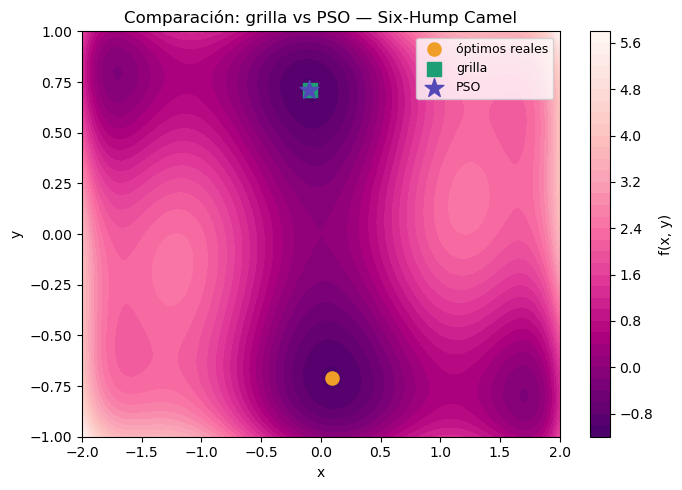

In [7]:
import numpy as np
import matplotlib.pyplot as plt

REFERENCIA = -1.031628

# ── Resultados obtenidos ───────────────────────────────────────
# (ejecuta las celdas anteriores primero)
metodos = {
    "Grilla (estructurada)": (x_grid,      y_grid,      f_grid),
    "PSO (Benítez 2014)":    (resultado[0], resultado[1], resultado[2]),
}

print(f"{'Método':<25} {'x':>10} {'y':>10} {'f(x,y)':>12} {'Error abs':>12}")
print("-" * 72)
for nombre, (x, y, f) in metodos.items():
    print(f"{nombre:<25} {x:>10.6f} {y:>10.6f} {f:>12.6f} {abs(f-REFERENCIA):>12.2e}")
print(f"\n{'Referencia':<25} {'±0.089843':>10} {'∓0.712656':>10} {REFERENCIA:>12.6f}")

# ── Gráfica comparativa ────────────────────────────────────────
x_r = np.linspace(-2, 2, 400)
y_r = np.linspace(-1, 1, 400)
X, Y = np.meshgrid(x_r, y_r)
Z = X**2*(4 - 2.1*X**2 + X**4/3) + X*Y + Y**2*(-4 + 4*Y**2)

fig, ax = plt.subplots(figsize=(7, 5))
cp_ = ax.contourf(X, Y, Z, levels=40, cmap="RdPu_r")
plt.colorbar(cp_, ax=ax, label="f(x, y)")

# Mínimos globales reales
ax.scatter([ 0.0898, -0.0898], [-0.7126,  0.7126],
           color="#EF9F27", s=90, zorder=6, label="óptimos reales")

# Resultado grilla
ax.scatter(x_grid, y_grid,
           color="#1D9E75", marker="s", s=100, zorder=7, label="grilla")

# Resultado PSO
ax.scatter(resultado[0], resultado[1],
           color="#534AB7", marker="*", s=200, zorder=8, label="PSO")

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Comparación: grilla vs PSO — Six-Hump Camel")
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()